In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

current_dir = Path.cwd()
script_dir = f'{current_dir.parent}/scripts'
sys.path.append(script_dir) 
from lib import load_nhanes_as_df, plot_sample_counts, box_plots
from lib import scatterplot_with_targets, box_plot_two_by_three, correlation_heatmap

# Dataset
######  Refined NHANES 2007-2012 spirometry dataset for the comparison of segmented (piecewise) linear models to that of GAMLSS
 
Downloaded from : https://data.mendeley.com/datasets/dwjykg3xww/1


[1] Zavorsky, Gerald (2024), “Refined NHANES 2007-2012 spirometry dataset for the comparison of segmented (piecewise) linear models to that of GAMLSS”, Mendeley Data, V1, doi: 10.17632/dwjykg3xww.1




### Dataset  Overview
(based on information provided on dataset website on Mendeley)

| Feature | Detail/Range | Notes |
| :--- | :--- | :--- |
| **Data Source** | National Health and Nutrition Examination Survey (NHANES) | Secondary data utilization. |
| **Survey Years** | 2007 - 2012 | Period of NHANES data used. |
| **Initial Participants** | 31,451 | Total participants in the initial NHANES pool. |
| **Refined Participants (Spirometry)** | **16,596** | Participants meeting technical quality standards. |
| **Age Range** | 6 - 80 years | Age of included participants. |
| **Racial/Ethnic Backgrounds** | Diverse | Study represents various racial and ethnic groups. |
| **Weight Range** | 16.4 - 218.2 kg | Range of participant weights. |
| **Height Range** | 104.6 - 203.8 cm | Range of participant heights. |
| **BMI Range** | 12.5 - 84.9 kg/m² | Range of participant Body Mass Index. |
| **Spirometry Quality Standard** | American Thoracic Society (2005) | Minimum technical quality standards (A and B maneuvers). |
| **Secondary Analysis** | Z-scores, Restrictive Pattern, Airway Obstruction | Calculated from GAMLSS and piecewise regression models using Lower Limit of Normal (LLN). |

In [2]:
df = load_nhanes_as_df()

In [3]:
df.head()

,SEQN,Sex,Race,Age,LnAge,Age2,Age3,Age_Groups,Height2_x_Race,Weight,...,LLN_FVC_5th_Segmented,LLN_FVC_2point5_Segmented,FEV1_FVC_Ratio_ULN_95th_Segmented,FEV1_FVC_Ratio_ULN_97point5_Segmented,FVC_ULN_95th_Segmented,FVC_ULN_97point5_Segmented,Baseline_FVC_Quality,Baseline_FEV1_Quality,Baseline_Number_Acceptable_Curves,Baseline_Effort_Quality
0,41475,Female,"Other race, including multi-racial",62.50,4.135167,3906.2500,244140.625000,60-69 yrs,95728.36,138.9,...,No,No,no,no,No,No,Exceeds ATS data collection standards: 3 accep...,Exceeds ATS data collection standards: 3 acce...,3,All 6 spirometry quality curves are acceptable
1,41476,Female,"Other race, including multi-racial",6.75,1.909543,45.5625,307.546875,6-9 yrs,57984.64,22.0,...,No,No,no,no,Yes,No,Exceeds ATS data collection standards: 3 accep...,Exceeds ATS data collection standards: 3 acce...,8,All 6 spirometry quality curves are acceptable
2,41479,Male,Mexican American,52.50,3.960813,2756.2500,144703.125000,50-59 yrs,47678.72,65.7,...,No,No,no,no,No,No,Exceeds ATS data collection standards: 3 accep...,Exceeds ATS data collection standards: 3 acce...,5,All 6 spirometry quality curves are acceptable
3,41481,Male,Black,21.25,3.056357,451.5625,9595.703125,20-29 yrs,33379.29,77.9,...,No,No,no,no,No,No,Exceeds ATS data collection standards: 3 accep...,Exceeds ATS data collection standards: 3 acce...,7,All 6 spirometry quality curves are acceptable
4,41482,Male,Mexican American,64.75,4.170534,4192.5625,271468.421875,60-69 yrs,60412.88,101.6,...,No,No,no,no,No,No,Meets ATS data collection standards: 3 accepta...,Exceeds ATS data collection standards: 3 acce...,7,All 6 spirometry quality curves are acceptable


In [4]:
df.shape

(16596, 73)

In [5]:
# Check columns in the dataset
df.columns

Index(['SEQN', 'Sex', 'Race', 'Age', 'LnAge', 'Age2', 'Age3', 'Age_Groups',
       'Height2_x_Race', 'Weight', 'Height', 'LnHeight', 'Height2',
       'Age_Height', 'Age_Height2', 'BMI', 'Baseline_FEV1_L', 'Baseline_FVC_L',
       'Baseline_FEV1_FVC_Ratio', 'Baseline_PEF_Ls', 'Baseline_FEF2575_Ls',
       'Baseline_Extrapolated_Volume', 'Baseline_Forced_Expiratory_Time',
       'FEV1_FVC_ratio_GLOBAL_Zscores', 'FEV1_Zscores_GLOBAL',
       'FVC_Zscores_GLOBAL', 'FEV1_ULN_GLOBAL', 'Ratio_Zscores_GAMLSS',
       'FVC_Zscores_GAMLSS', 'FEV1_Zscores_GAMLSS', 'Ratio_Zscores_Linear',
       'FEV1_Zscores_Segmented', 'FVC_Zscores_Segmented',
       'Normal_5th_Segmented', 'Normal_5th_GAMLSS', 'Normal_2point5_Segmented',
       'Normal_2point5_GAMLSS', 'Obstruction_5th_Segmented',
       'Obstruction_5th_GAMLSS', 'Obstruction_2point5_Segmented',
       'Obstruction_2point5_GAMLSS',
       'Restrictive_Spirometry_Pattern_5th_Segmented',
       'Restrictive_Spirometry_Pattern_5th_GAMLSS',
      

### Initial Observation of data

 - Demographic Data

| Category | Variables | Notes |
| :--- | :--- | :--- |
| **Age-related** | Age, LnAge, Age², Age³ | Includes transformations (natural log and polynomial). |
| **Anthropometrics** | Height, LnHeight, Height², Weight, BMI | Body size and composition measurements. |
| **Interaction Terms** | Age_Height, Age_Height², Height² x Race | Used for statistical modeling. |
| **Categorical** | Race, Sex, Age_Groups | Variables used for grouping or classification. |

- Statistical Modeling Variables

| Category | Variables | Type/Use |
| :--- | :--- | :--- |
| **Response Variables** | FEV1, FVC, FEV1/FVC | Dependent variables; main outcomes of interest. |
| **Fixed Effects** | Age, Sex, Height, Race | Variables whose effects are assumed constant across the population. |
| **Random Effects** | Age_Groups, Survey_Wave | Variables with effects that may vary or are sampled from a larger population (common in mixed-effects models). |


NB: 
- Forced Expiratory Volume in 1 s ( **FEV1** ): Air exhaled forcefully in **one second**. 
- Forced Vital Capacity (**FVC**): **Total** air exhaled during a forced breath.
- FEV1/FVC Ratio (**FEV1/FVC**): Ratio for diagnosing **airflow obstruction**. 

###### Baseline Measurements ()Raw Spirometry data)
- Baseline_FEV1_L
- Baseline_FVC_L
- Baseline_FEV1_FVC_Ratio
- Baseline_PEF_Ls
- Baseline_FEF2575_Ls

In [6]:
demographic_data = ['Age', 'LnAge', 'Age2', 'Age3','Age_Groups',
 'Sex', 'Race',
 'Height', 'LnHeight', 'Height2',
 'Weight', 'BMI',
 'Height2_x_Race',
 'Age_Height', 'Age_Height2']

target_variables = ['Baseline_FEV1_L',
 'Baseline_FVC_L',
 'Baseline_FEV1_FVC_Ratio']

selected_columns = demographic_data + target_variables
df = df[selected_columns]
df.head()

,Age,LnAge,Age2,Age3,Age_Groups,Sex,Race,Height,LnHeight,Height2,Weight,BMI,Height2_x_Race,Age_Height,Age_Height2,Baseline_FEV1_L,Baseline_FVC_L,Baseline_FEV1_FVC_Ratio
0,62.50,4.135167,3906.2500,244140.625000,60-69 yrs,Female,"Other race, including multi-racial",154.7,5.041488,23932.09,138.9,58.04,95728.36,9668.750,1.495756e+06,2.025,2.473,0.818844
1,6.75,1.909543,45.5625,307.546875,6-9 yrs,Female,"Other race, including multi-racial",120.4,4.790820,14496.16,22.0,15.18,57984.64,812.700,9.784908e+04,1.551,1.742,0.890356
2,52.50,3.960813,2756.2500,144703.125000,50-59 yrs,Male,Mexican American,154.4,5.039547,23839.36,65.7,27.56,47678.72,8106.000,1.251566e+06,2.957,3.545,0.834133
3,21.25,3.056357,451.5625,9595.703125,20-29 yrs,Male,Black,182.7,5.207845,33379.29,77.9,23.34,33379.29,3882.375,7.093099e+05,4.541,4.928,0.921469
4,64.75,4.170534,4192.5625,271468.421875,60-69 yrs,Male,Mexican American,173.8,5.157905,30206.44,101.6,33.64,60412.88,11253.550,1.955867e+06,2.920,3.907,0.747377


In [7]:
df.shape

(16596, 18)

In [8]:
desc = df.describe(include='all')
styled_desc = desc.style.background_gradient(cmap="Greens")
styled_desc

,Age,LnAge,Age2,Age3,Age_Groups,Sex,Race,Height,LnHeight,Height2,Weight,BMI,Height2_x_Race,Age_Height,Age_Height2,Baseline_FEV1_L,Baseline_FVC_L,Baseline_FEV1_FVC_Ratio
count,16596.000000,16596.000000,16596.000000,16596.000000,16596,16596,16596,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000,16596.000000
unique,nan,nan,nan,nan,8,2,5,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
top,nan,nan,nan,nan,10-19 yrs,Female,White,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
freq,nan,nan,nan,nan,3638,8303,6607,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
mean,35.888211,3.370220,1716.099199,94932.668261,nan,nan,nan,162.851934,5.088231,26748.497065,72.966564,26.821605,32947.469529,5967.539484,997019.339015,2.948338,3.675757,0.806434
std,20.692059,0.697624,1655.898386,119799.427203,nan,nan,nan,15.091664,0.097889,4727.042288,25.680759,7.355476,35040.552344,3515.269793,605707.151529,0.952432,1.177960,0.083266
min,6.000000,1.791759,36.000000,216.000000,nan,nan,nan,104.600000,4.650144,10941.160000,16.400000,12.500000,0.000000,627.600000,65646.960000,0.476000,0.704000,0.291286
25%,17.000000,2.833213,289.000000,4913.000000,nan,nan,nan,155.900000,5.049215,24304.810000,57.200000,21.680000,0.000000,2801.168750,466760.330000,2.224000,2.814750,0.760395
50%,34.000000,3.526361,1156.000000,39304.000000,nan,nan,nan,164.800000,5.104733,27159.040000,72.300000,26.070000,27357.160000,5744.125000,967460.695000,2.910500,3.630000,0.814672
75%,53.000000,3.970292,2809.000000,148877.000000,nan,nan,nan,173.200000,5.154447,29998.240000,88.200000,30.900000,54648.180000,8850.918750,1474176.451250,3.598250,4.480000,0.861980


In [9]:
# For ease of visualization shortening the value
df['Race'] = df['Race'].replace('Other race, including multi-racial', 'Other_or_multi-racial')
df['Race'].unique()

array(['Other_or_multi-racial', 'Mexican American', 'Black', 'White',
       'Other hispanic'], dtype=object)

# 1. Univariate Analysis (Distribution and Frequency)

Histograms to check for skewness, normality, and central tendency.

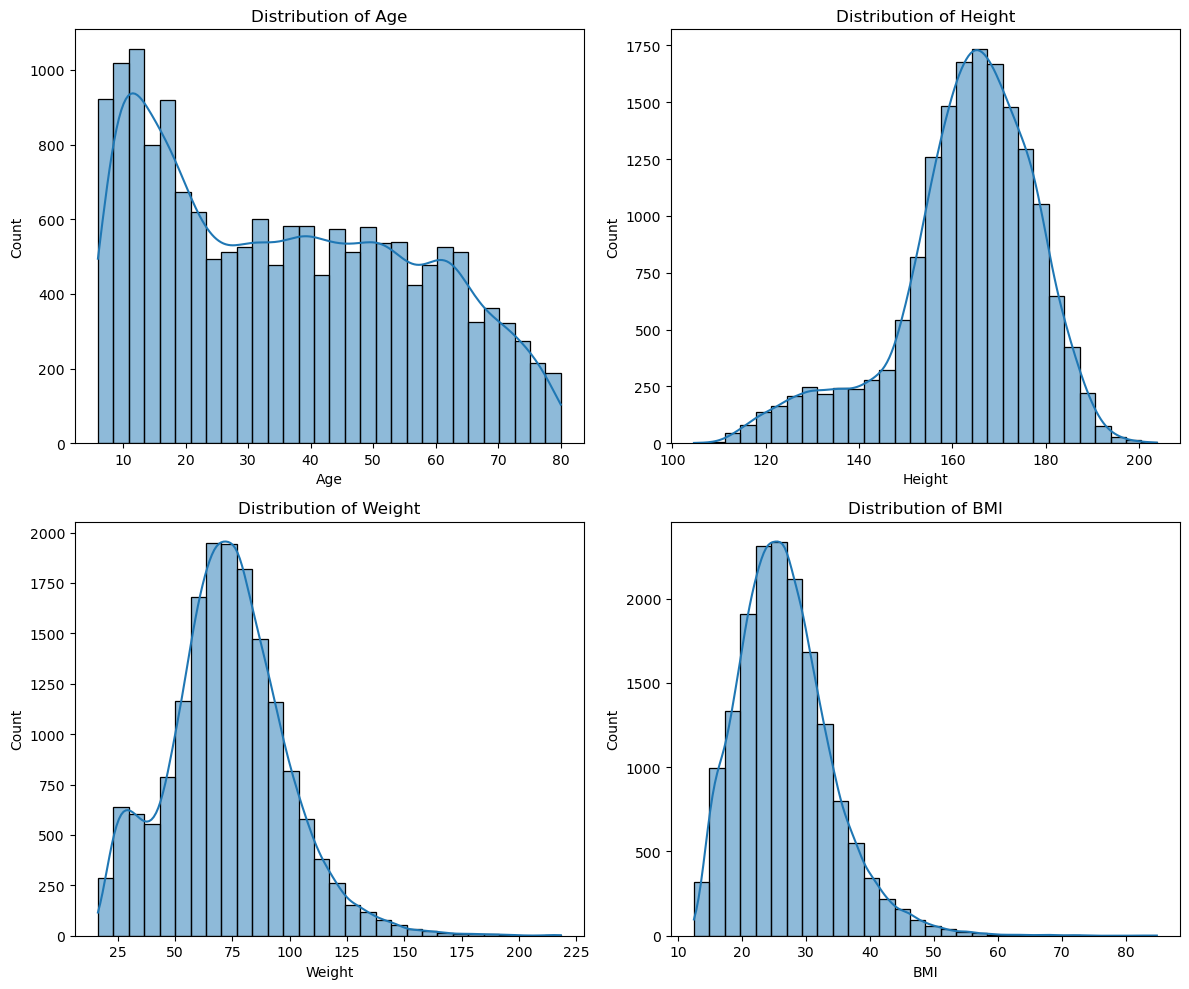

In [10]:
variables = ['Age', 'Height', 'Weight', 'BMI']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(data=df, x=var, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
plt.tight_layout()
plt.show()

Let's plot the value counts

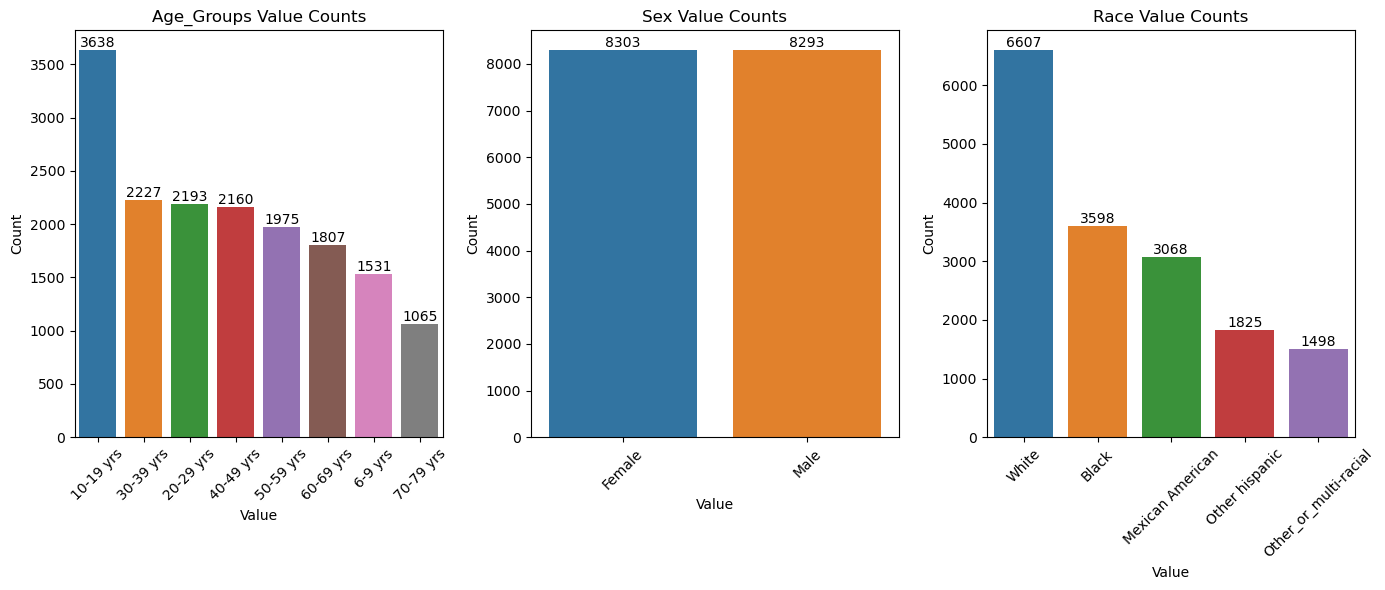

In [11]:
columns = ['Age_Groups', 'Sex', 'Race']  
fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes = axes.flatten()
for i, col in enumerate(columns):
    plot_sample_counts(col, df, ax=axes[i])
plt.tight_layout()
plt.show()

# 2. Bivariate Analysis (Relationships)

Scatter Plot to see the nature of the relationship (linear, non-linear, positive, negative) between continuous variable.

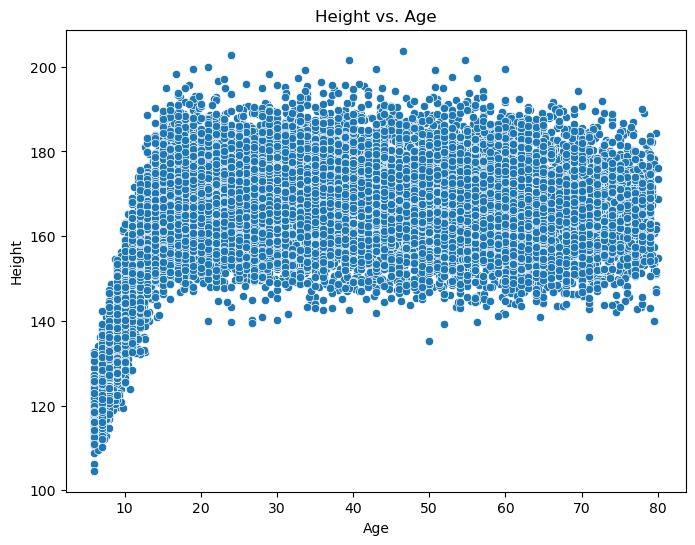

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Height')
plt.title('Height vs. Age')
plt.show()

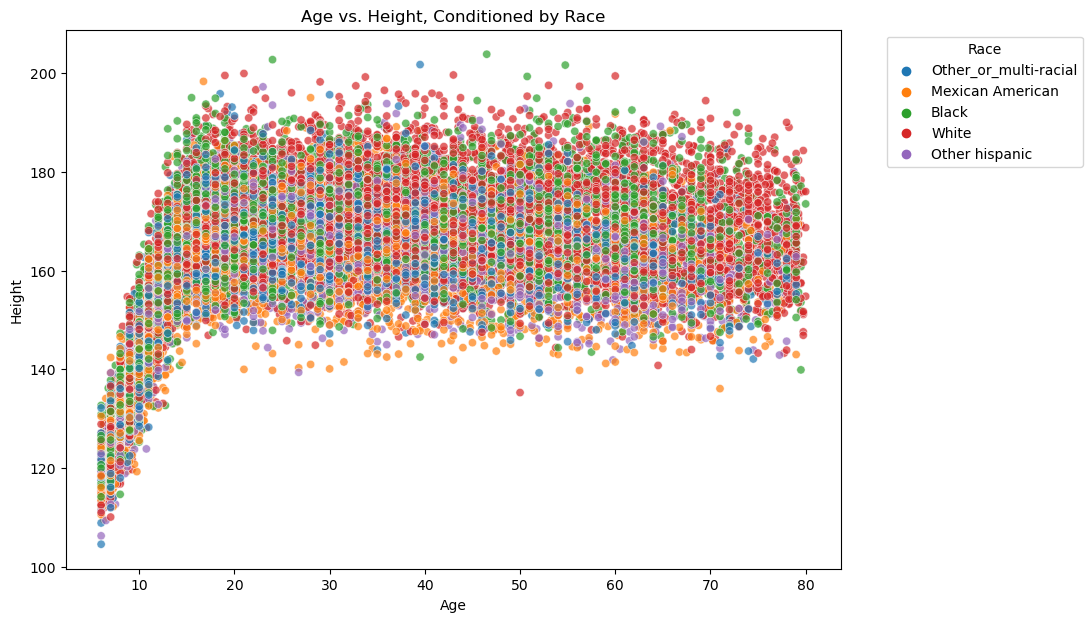

In [13]:
#Interaction Effects (Age_Height interaction conditioned on Race)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Age', y='Height', hue='Race', alpha=0.7)
plt.title('Age vs. Height, Conditioned by Race')
plt.legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Box Plot to compare the distribution of a continuous variables across different age groups and sex.

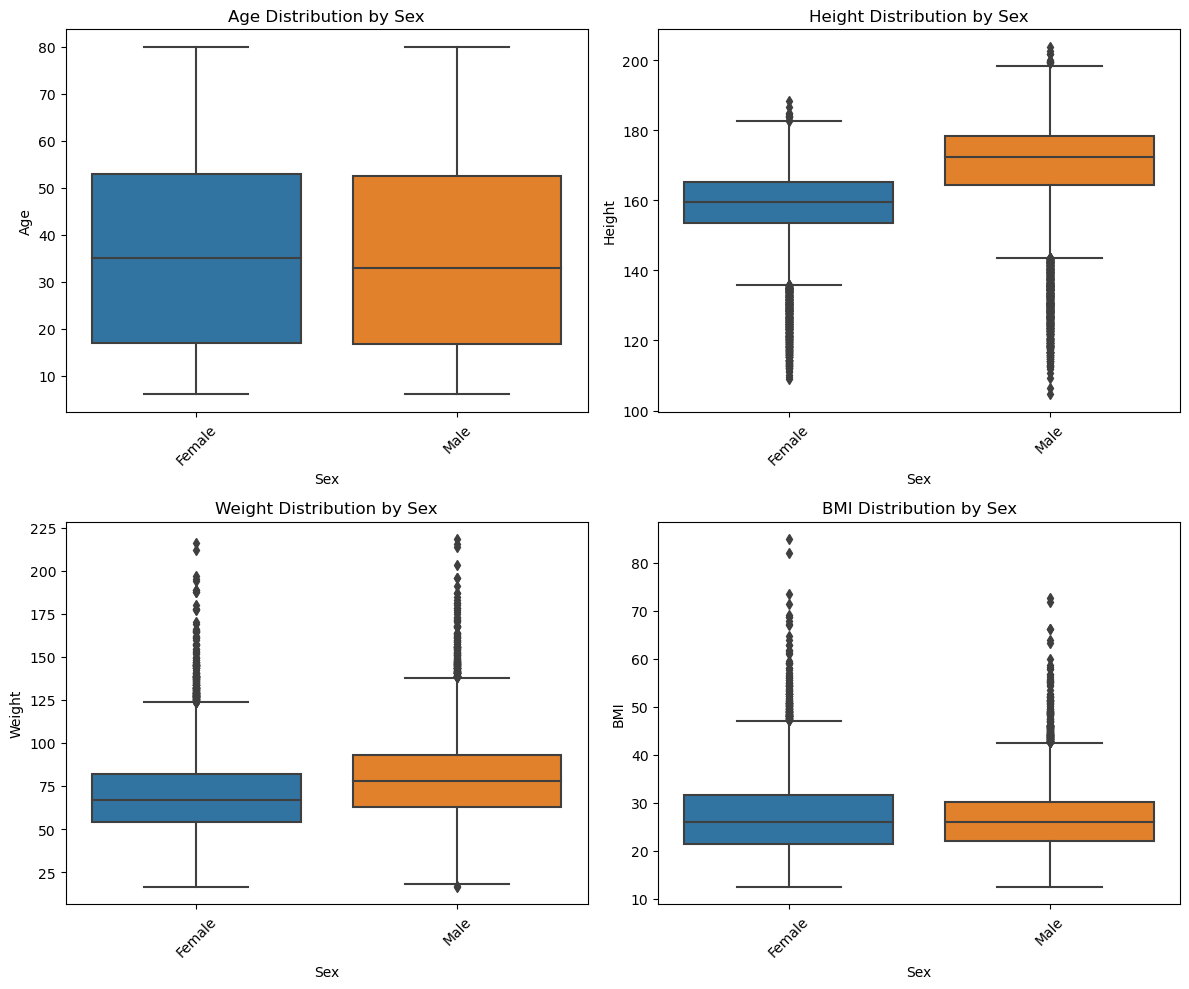

In [14]:
box_plots(df, 'Sex', ['Age', 'Height', 'Weight', 'BMI'])

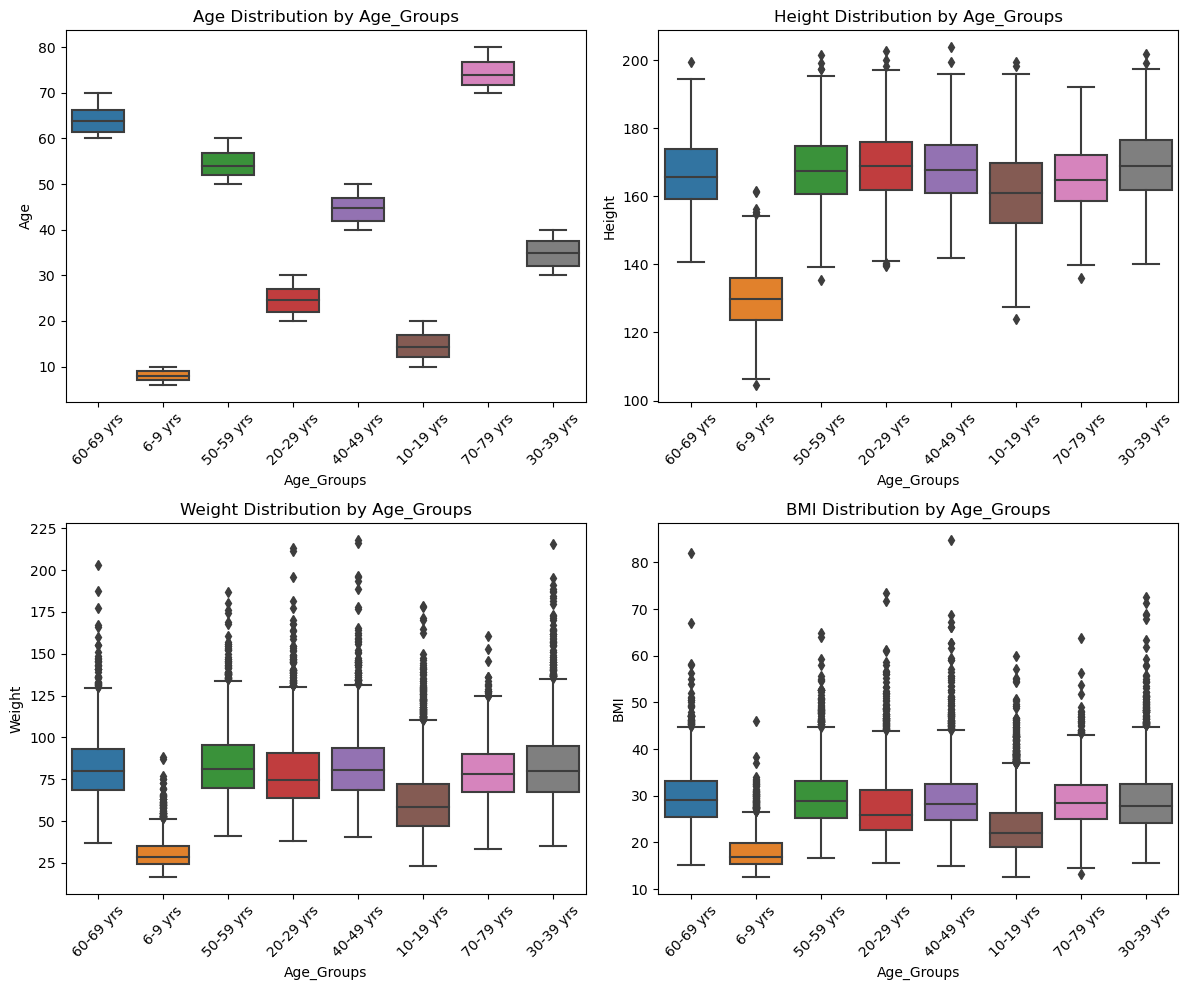

In [15]:
box_plots(df, 'Age_Groups', ['Age', 'Height', 'Weight', 'BMI'])

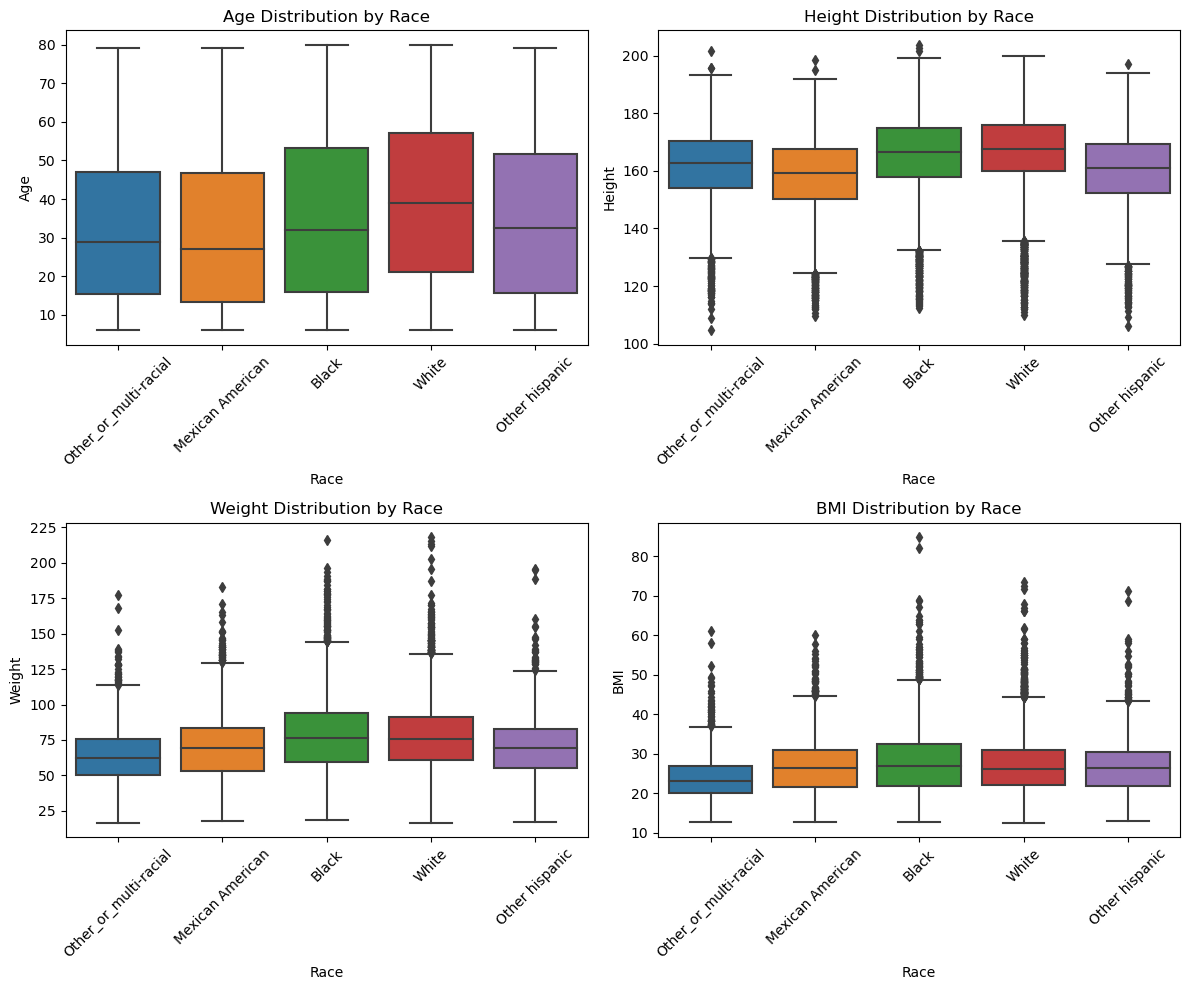

In [16]:
box_plots(df, 'Race', ['Age', 'Height', 'Weight', 'BMI'])

# Correlation Heatmap

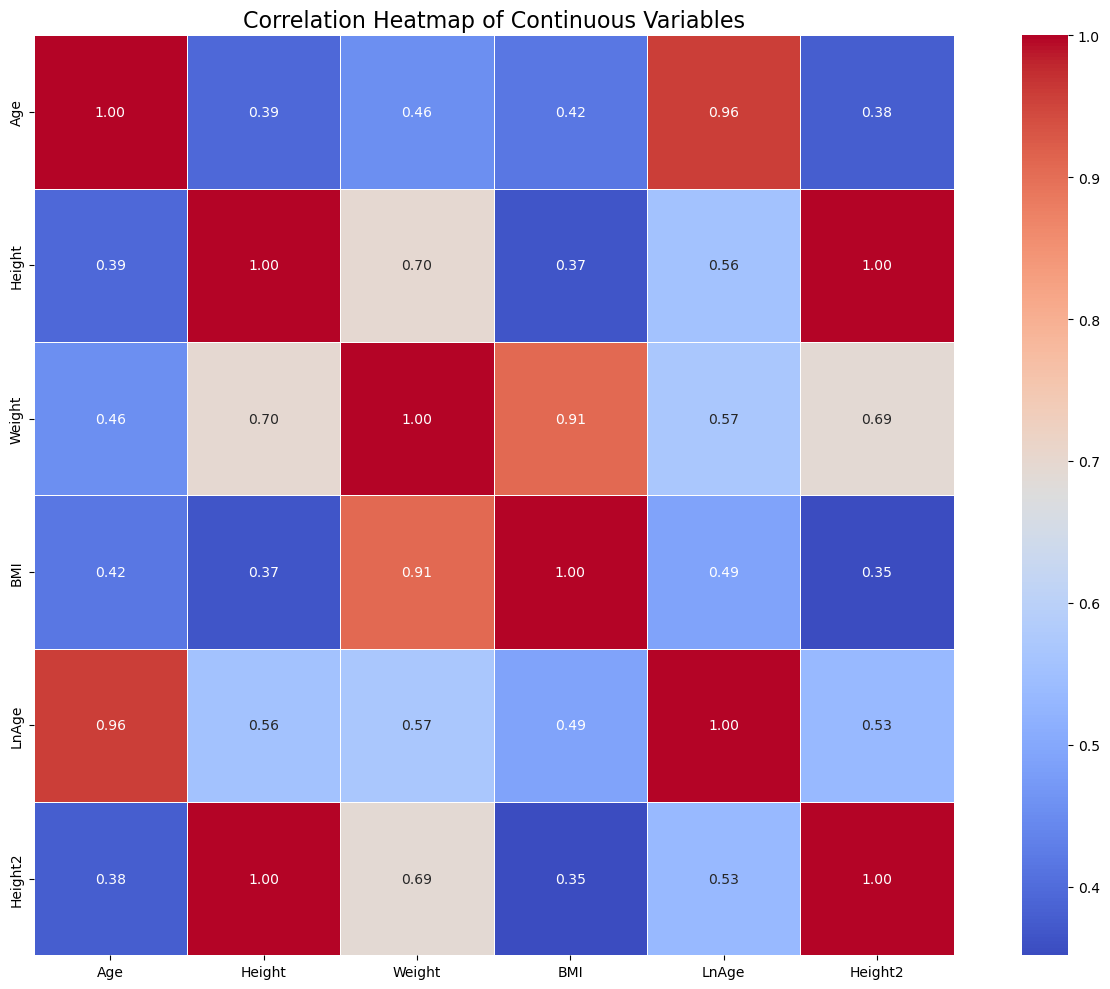

In [17]:
continuous_vars = ['Age', 'Height', 'Weight', 'BMI', 'LnAge', 'Height2']
correlation_heatmap(df, continuous_vars, "Correlation Heatmap of Continuous Variables")

# Plotting Age with Target Variables

In [18]:
targets = [
    ('Baseline_FEV1_L', 'FEV1 (L)'),
    ('Baseline_FVC_L', 'FVC (L)'),
    ('Baseline_FEV1_FVC_Ratio', 'FEV1/FVC Ratio')
]

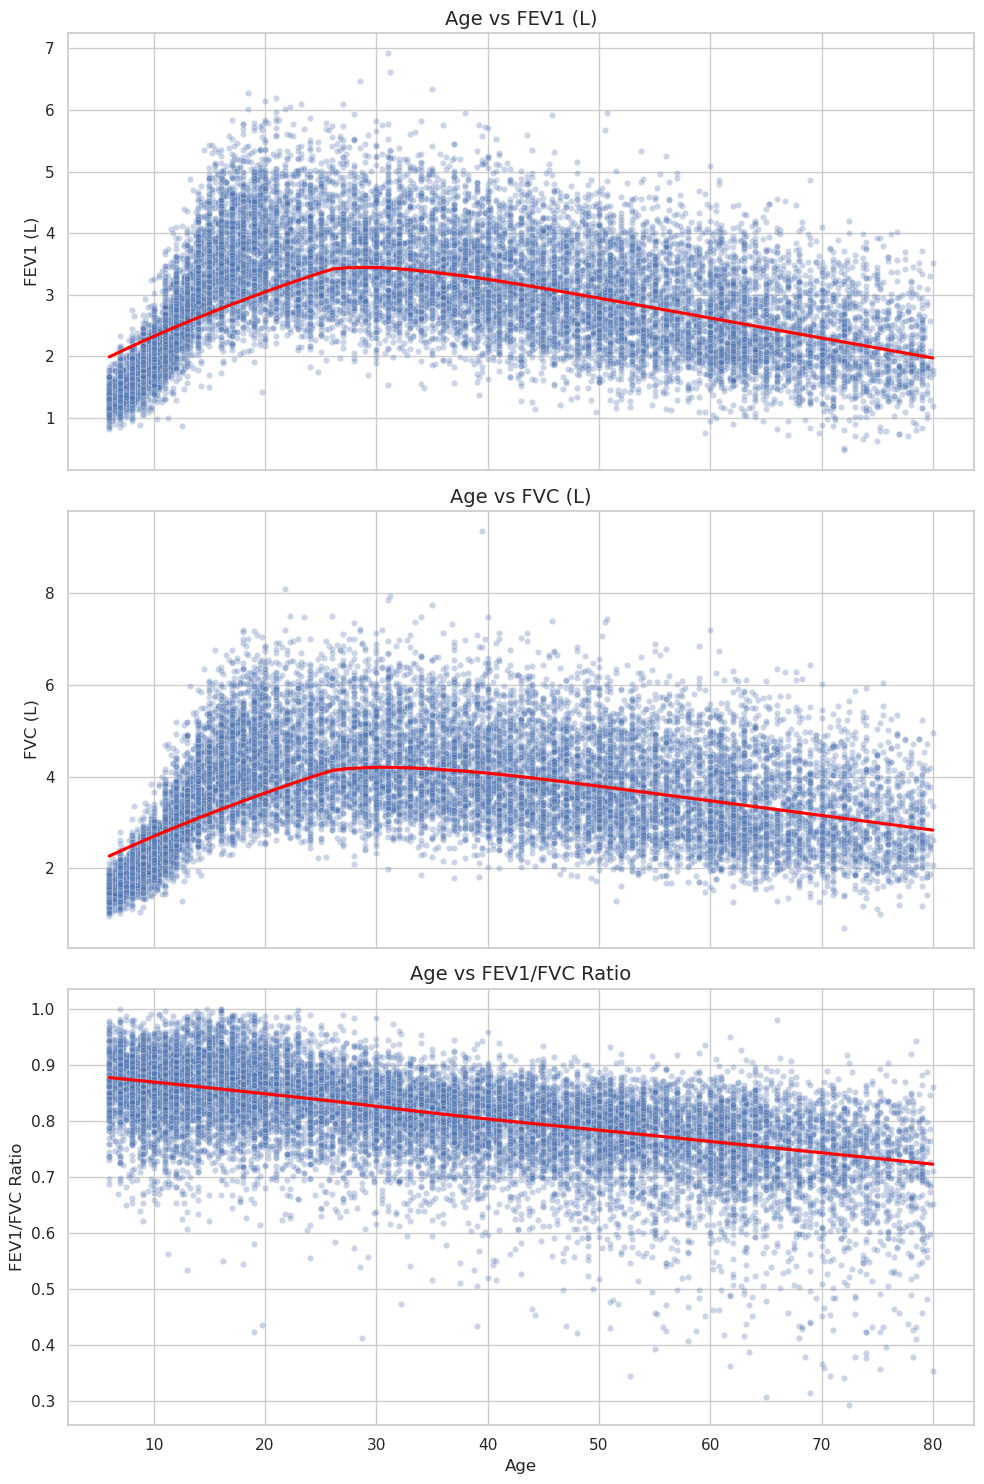

In [19]:
scatterplot_with_targets(df, "Age", targets)

Age v/s FEV1, FVC, and FEV1/FVC ratio plots show the expected physiological patterns: increasing lung function in early adulthood followed by age-related decline.

# Plotting Weight with Target Variables

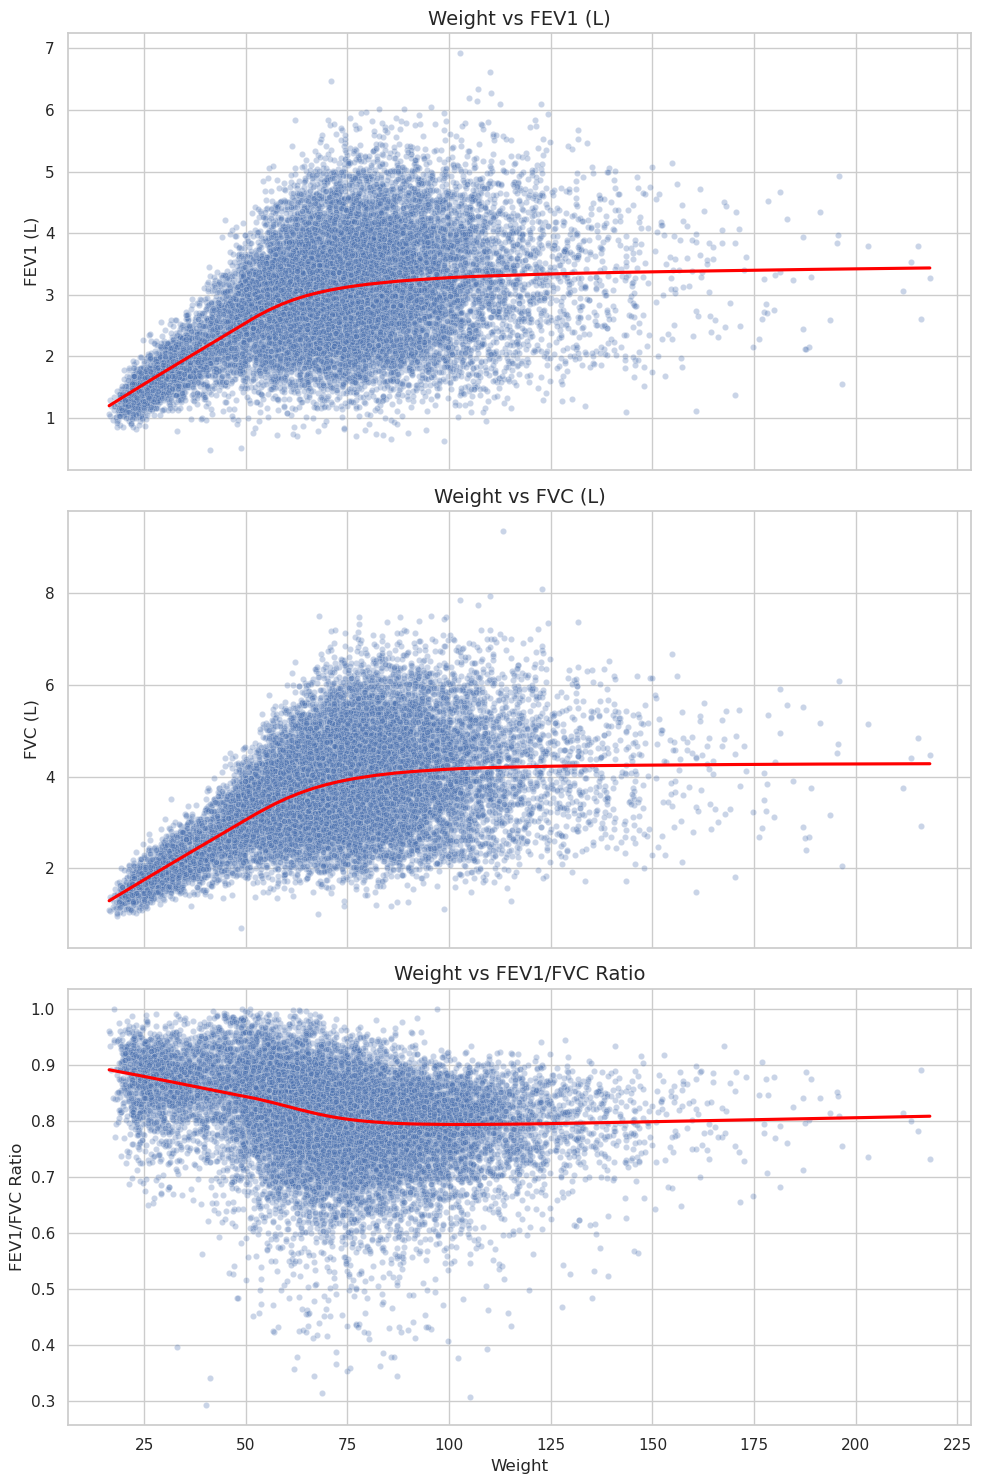

In [20]:
scatterplot_with_targets(df, "Weight", targets)

# Plotting Sex with Target Variables

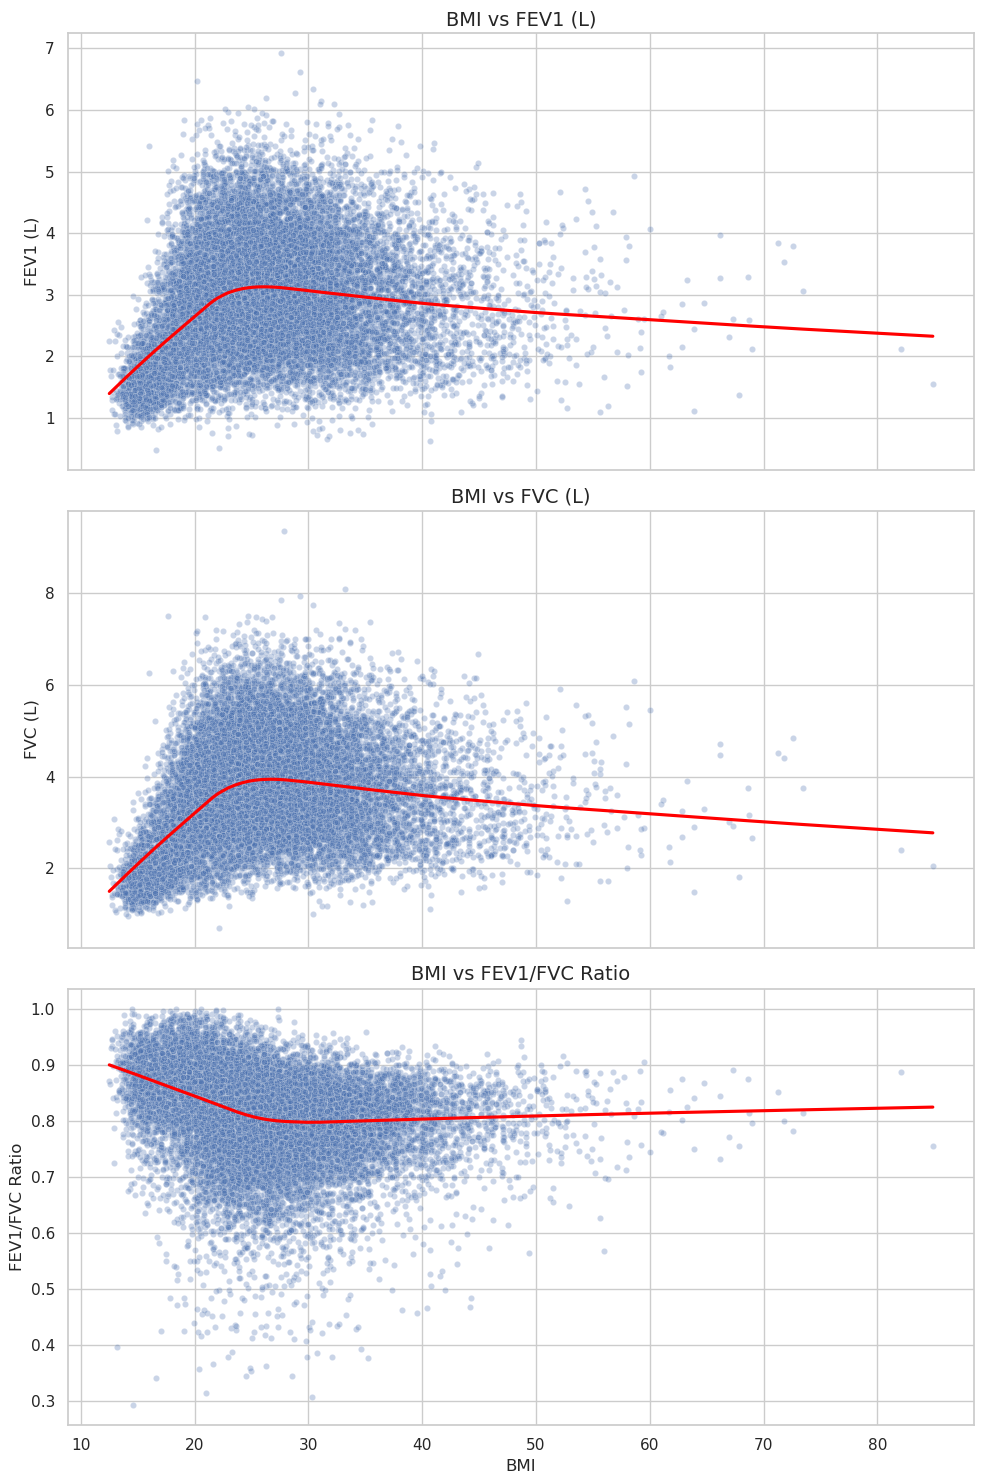

In [21]:
scatterplot_with_targets(df, "BMI", targets)

# Boxplots of targets by Sex and Race 

Plotting distribution of three key spirometry measurements—FEV1, FVC, and the FEV1/FVC Ratio when segmented by the categorical variables Sex and Race/Ethnicity.

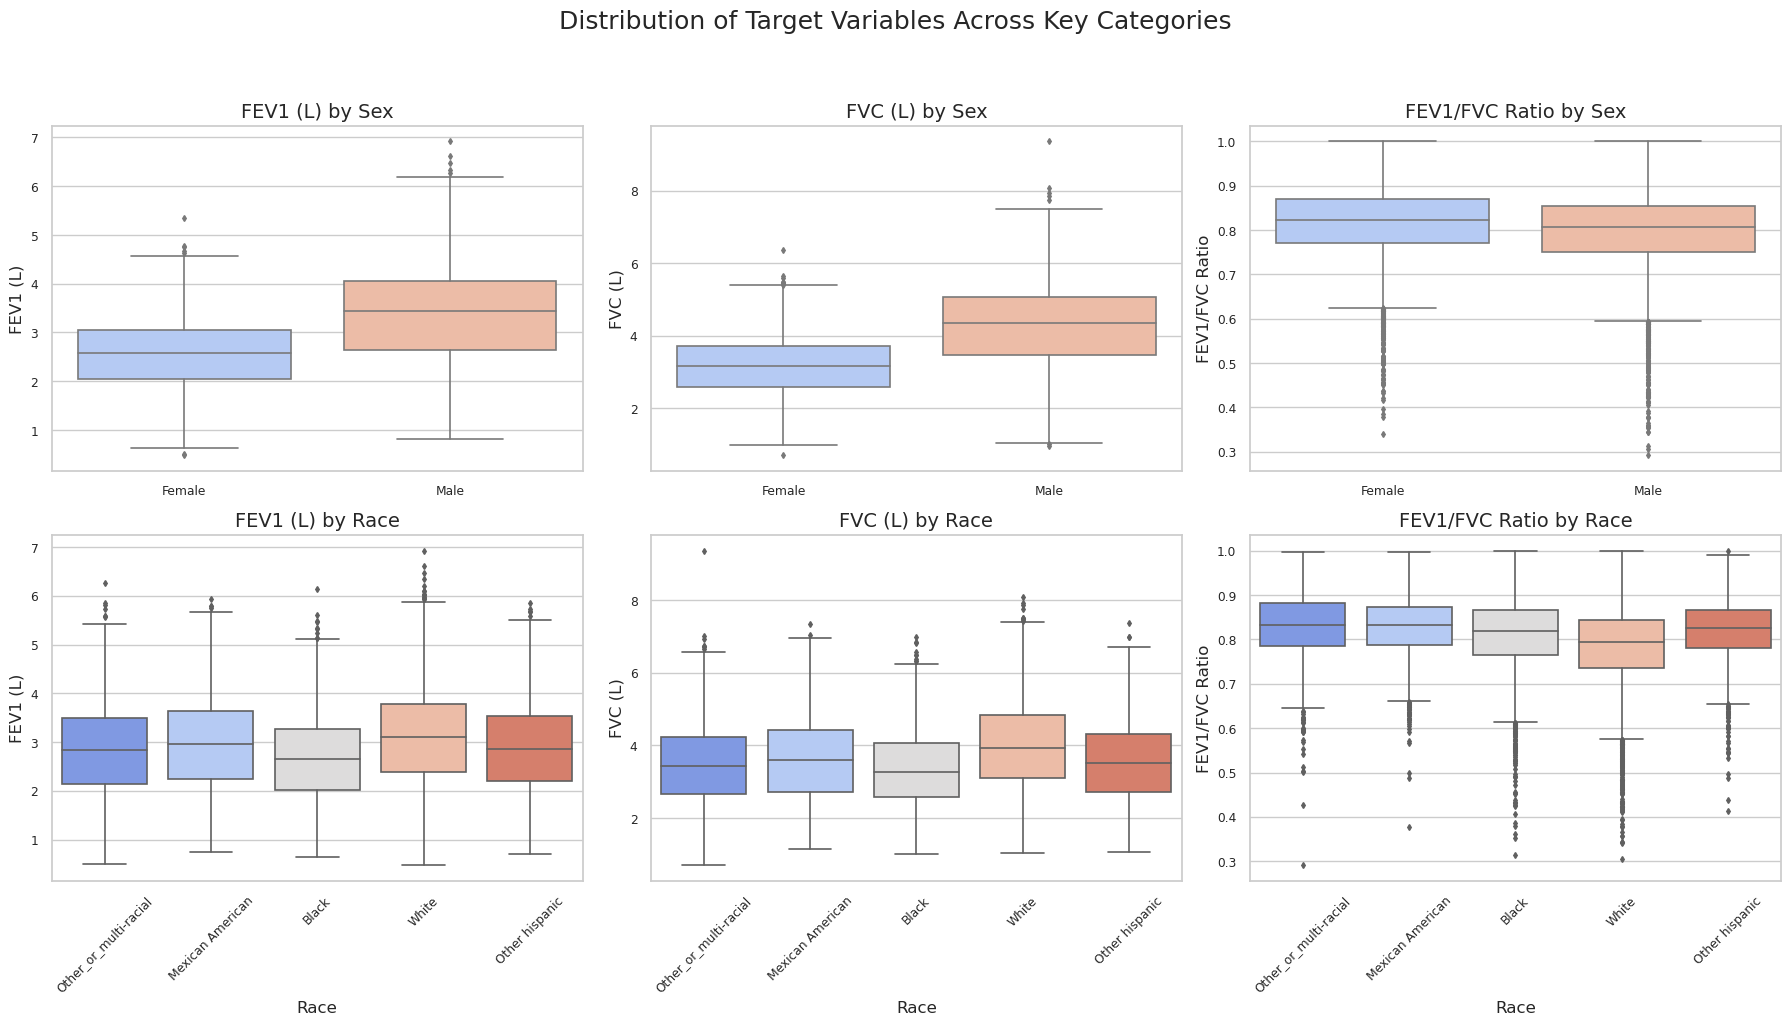

In [22]:
targets = [
    ('Baseline_FEV1_L', 'FEV1 (L)'),
    ('Baseline_FVC_L', 'FVC (L)'),
    ('Baseline_FEV1_FVC_Ratio', 'FEV1/FVC Ratio')
]
box_plot_two_by_three(df, ['Sex', 'Race'], targets)

- Sex is a Major Predictor of Volume: Sex is a strong differentiator for absolute lung volumes (FEV1 and FVC), which is a crucial factor to account for in any lung function modeling (often done by including sex, height, and age as key covariates).

- Ratio is Consistent: Neither sex nor race appears to be a strong predictor of the FEV1/FVC Ratio. This consistency across groups supports the methodology of using standardized z-scores to compare individuals against population norms, often with race and sex included in the reference equations.

- Potential Airflow Obstruction: The numerous low outliers in the FEV1/FVC ratio plots are important. They identify the population subgroup with potential airway obstruction, which is often a key outcome variable in respiratory studies.

# Correlation heatmap for predictors + targets

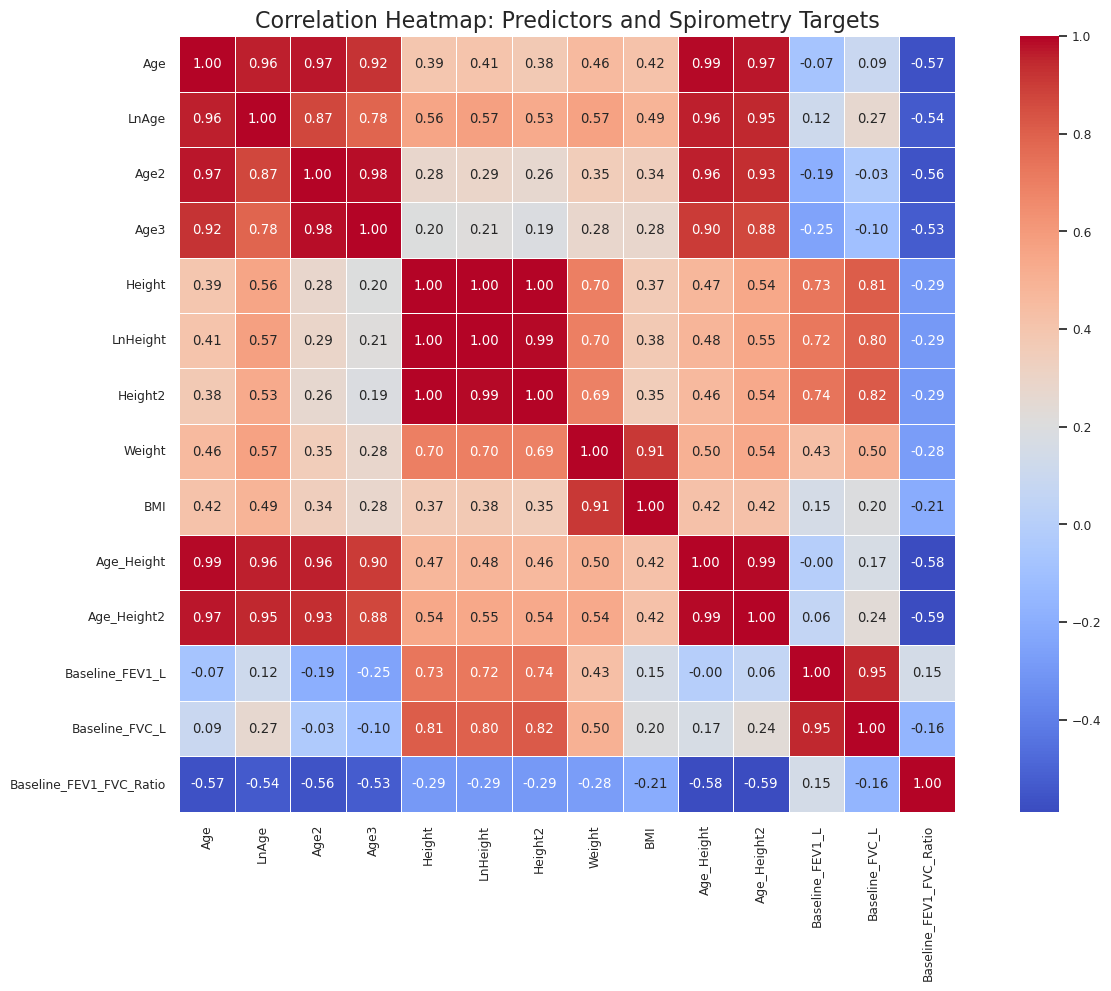

In [23]:

corr_cols = [
    'Age', 'LnAge', 'Age2', 'Age3',
    'Height', 'LnHeight', 'Height2',
    'Weight', 'BMI',
    'Age_Height', 'Age_Height2',
    'Baseline_FEV1_L',
    'Baseline_FVC_L',
    'Baseline_FEV1_FVC_Ratio'
]
correlation_heatmap(df, corr_cols, "Correlation Heatmap: Predictors and Spirometry Targets")

- Multicollinearity is Severe among the mathematically transformed predictor variables (Age terms, Height terms, Interaction terms). 

**Modeling must address this, likely through variable selection or regularization.** 

- Height is the most influential factor for absolute lung volume (FEV1 and FVC).

- Age is the most influential factor for the FEV1/FVC Ratio, showing a significant decline with increasing age.
---
##### Within target variables
- FEV1 (L) and FVC (L): Very Strong Positive Correlation ($r = 0.95$). This is expected, as FEV1 is the amount of air exhaled in the first second, and FVC is the total amount exhaled. If FVC is high, FEV1 is usually high as well.FEV1/FVC Ratio vs. 
- FEV1 (L) and FVC (L): Weak to Moderate Negative Correlation ($r \approx -0.10$ to $-0.16$). The ratio is negatively related to the absolute lung volumes.

In [24]:
targets = [
    'Baseline_FEV1_L',
    'Baseline_FVC_L',
    'Baseline_FEV1_FVC_Ratio'
]

 
summary = df.groupby('Age_Groups')[targets].agg(['mean', 'std'])
formatted_summary = summary.copy()
for t in targets:
    formatted_summary[(t, 'mean±sd')] = (
        summary[(t, 'mean')].round(2).astype(str)
        + " ± "
        + summary[(t, 'std')].round(2).astype(str)
    )

summary_table = formatted_summary.loc[:, [(t, 'mean±sd') for t in targets]]
summary_table

,Baseline_FEV1_L,Baseline_FVC_L,Baseline_FEV1_FVC_Ratio
,mean±sd,mean±sd,mean±sd
Age_Groups,,,
10-19 yrs,3.11 ± 0.89,3.63 ± 1.05,0.86 ± 0.06
20-29 yrs,3.69 ± 0.78,4.45 ± 0.98,0.83 ± 0.06
30-39 yrs,3.49 ± 0.77,4.36 ± 0.98,0.8 ± 0.06
40-49 yrs,3.15 ± 0.75,4.02 ± 0.98,0.79 ± 0.07
50-59 yrs,2.85 ± 0.74,3.74 ± 0.99,0.77 ± 0.07
6-9 yrs,1.62 ± 0.34,1.88 ± 0.4,0.86 ± 0.06
60-69 yrs,2.51 ± 0.7,3.39 ± 0.96,0.74 ± 0.08
70-79 yrs,2.19 ± 0.65,3.08 ± 0.89,0.71 ± 0.09


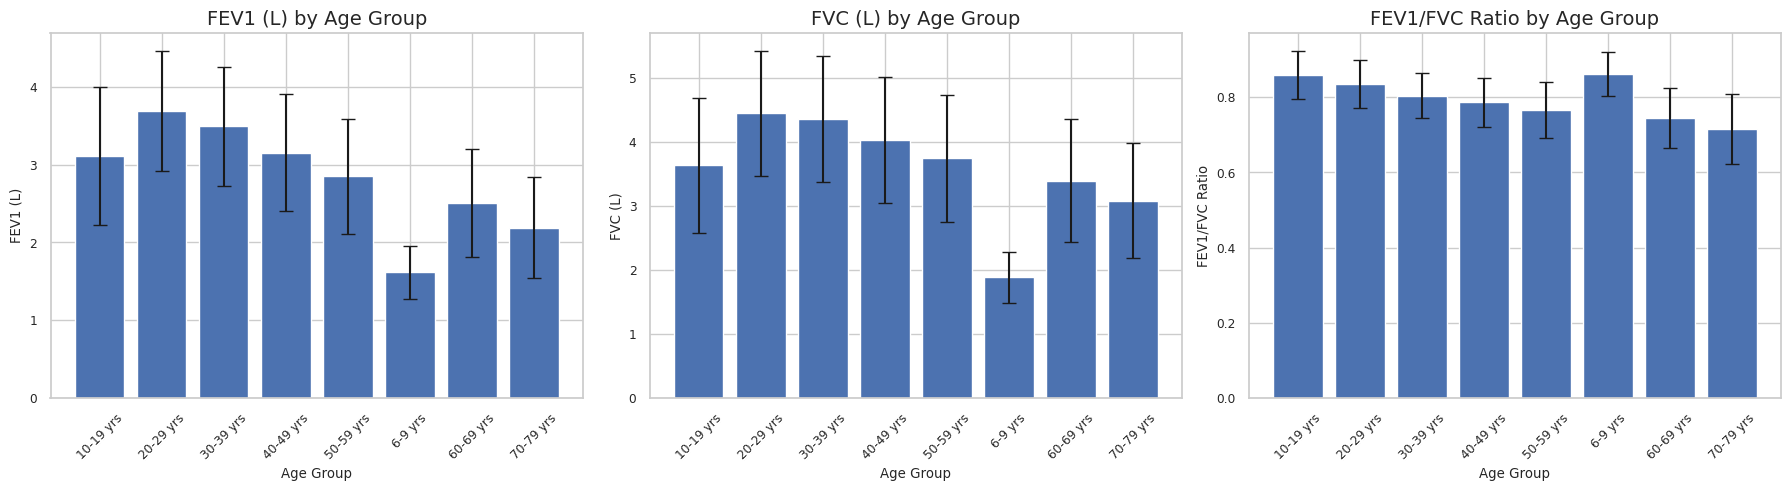

In [25]:
age_groups = summary_table.index
targets = [
    'Baseline_FEV1_L',
    'Baseline_FVC_L',
    'Baseline_FEV1_FVC_Ratio'
]

labels = {
    'Baseline_FEV1_L': 'FEV1 (L)',
    'Baseline_FVC_L': 'FVC (L)',
    'Baseline_FEV1_FVC_Ratio': 'FEV1/FVC Ratio'
}


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

for ax, t in zip(axes, targets): 
    mean_vals = summary[(t, 'mean')].loc[age_groups]
    sd_vals = summary[(t, 'std')].loc[age_groups]

    ax.bar(age_groups, mean_vals, yerr=sd_vals, capsize=5)
    ax.set_title(f"{labels[t]} by Age Group", fontsize=14)
    ax.set_xlabel("Age Group")
    ax.set_ylabel(labels[t])
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

As expected, mean FEV1 and FVC decline with increasing age groups, while the FEV1/FVC ratio also decreases progressively.